In [1]:
%cd /home/young/projects/pokemon_diffusion
%reload_ext kedro.ipython

/home/young/projects/pokemon_diffusion


[06/11/26 12:44:18] INFO     Using                                                                  ]8;id=14402993;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=14402994;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/framework/project/__init__.py#275\275]8;;\
                             '/home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-package                
                             s/kedro/framework/project/rich_logging.yml' as logging configuration.                 

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=14403001;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14403002;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/ipython/__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=14403008;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14403009;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/ipython/__init__.py#66\66]8;;\

                    INFO     Resolved project path as: /home/young/projects/pokemon_diffusion.      ]8;id=14403015;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14403016;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/ipython/__init__.py#181\181]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 12:44:24] INFO     No typed parameter requirements found, returning original   ]8;id=14403023;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/validation/parameter_validator.py\parameter_validator.py]8;;\:]8;id=14403024;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/validation/parameter_validator.py#108\108]8;;\
                             parameters                                                                            

[06/11/26 12:44:25] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=14403031;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=14403032;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro_telemetry/plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

                    INFO     Kedro project pokemon_diffusion                                        ]8;id=14403038;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14403039;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/ipython/__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=14403045;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14403046;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/ipython/__init__.py#148\148]8;;\
                             'pipelines'                                                                           

In [ ]:
from pokemon_diffusion.training.datamodule import create_dataloaders

params = catalog.load("params:vae")
train_metadata = catalog.load("train_metadata")
val_metadata = catalog.load("val_metadata")

train_loader, val_loader = create_dataloaders(
    train_metadata=train_metadata,
    val_metadata=val_metadata,
    img_size=params["data"]["img_size"],
    batch_size=500,
    normalization_range="minus_one_to_one",
    num_workers=params["data"].get("num_workers", 2),
)

                    INFO     Loading data from params:vae (MemoryDataset)...                   ]8;id=14403053;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=14403054;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/io/data_catalog.py#1053\1053]8;;\

                    INFO     Loading data from train_metadata (CSVDataset)...                  ]8;id=14403059;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=14403060;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/io/data_catalog.py#1053\1053]8;;\

                    INFO     Loading data from val_metadata (CSVDataset)...                    ]8;id=14403065;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=14403066;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/kedro/io/data_catalog.py#1053\1053]8;;\

In [5]:
import torch
from pokemon_diffusion.models.res_vae import VAE
from pokemon_diffusion.training.loss import ForegroundWeightedLoss, VGGFeatureLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE(
    img_size=params["data"]["img_size"],
    latent_dim=params["model"]["latent_dim"],
    activation=params["model"]["activation"],
    norm_type=params["model"]["norm_type"],
    output_activation=params["model"]["output_activation"],
    base_channels=params["model"]["base_channels"],
).to(device)

fg_loss = ForegroundWeightedLoss(
    base_loss=params["training"].get("recon_loss", "l1"),
    normalization_range=params["data"]["normalization_range"],
    threshold=params["training"].get("foreground_threshold", 0.95),
    foreground_weight=params["training"].get("foreground_weight", 4.0),
)

vgg_loss = VGGFeatureLoss(
    normalization_range=params["data"]["normalization_range"]
)

In [7]:
import torch.nn.functional as F
from tqdm import tqdm

vgg_weight = 0.1
beta = params["training"].get("beta", 0.00001)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=params["training"]["learning_rate"],
    weight_decay=params["training"].get("weight_decay", 0.0),
)

fg_loss = fg_loss.to(device)
vgg_loss = vgg_loss.to(device)

model.train()

for batch_idx, batch in enumerate(tqdm(train_loader)):
    x = batch["image"].to(device)

    optimizer.zero_grad()
    recon, mu, logvar = model(x)

    loss_fg = fg_loss(recon, x)
    loss_vgg = vgg_loss(recon, x)

    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = loss_fg + vgg_weight * loss_vgg + beta * kl

    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if batch_idx % 20 == 0:
        print(
            f"batch {batch_idx} | "
            f"fg: {loss_fg.item():.6f} | "
            f"vgg_raw: {loss_vgg.item():.6f} | "
            f"vgg_weighted: {(vgg_weight * loss_vgg).item():.6f} | "
            f"kl: {kl.item():.6f} | "
            f"kl_weighted: {(beta * kl).item():.6f} | "
            f"total: {total_loss.item():.6f}"
        )

  4%|▍         | 1/26 [00:10<04:15, 10.22s/it]

batch 0 | fg: 1.483041 | vgg_raw: 7.851677 | vgg_weighted: 0.785168 | kl: 1.400985 | kl_weighted: 0.000140 | total: 2.268349


 81%|████████  | 21/26 [04:13<01:18, 15.75s/it]

batch 20 | fg: 1.353105 | vgg_raw: 6.132883 | vgg_weighted: 0.613288 | kl: 2.046364 | kl_weighted: 0.000205 | total: 1.966598


100%|██████████| 26/26 [04:52<00:00, 11.25s/it]


[06/11/26 12:54:34] WARNING  Clipping input data to the valid range for imshow with RGB data ([0..1]   ]8;id=14403073;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py\image.py]8;;\:]8;id=14403074;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py#661\661]8;;\
                             for floats or [0..255] for integers). Got range [-0.8745098..1.0].                    

                    WARNING  Clipping input data to the valid range for imshow with RGB data ([0..1]   ]8;id=14403079;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py\image.py]8;;\:]8;id=14403080;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py#661\661]8;;\
                             for floats or [0..255] for integers). Got range [-1.0..1.0].                          

                    WARNING  Clipping input data to the valid range for imshow with RGB data ([0..1]   ]8;id=14403085;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py\image.py]8;;\:]8;id=14403086;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py#661\661]8;;\
                             for floats or [0..255] for integers). Got range [-1.0..1.0].                          

                    WARNING  Clipping input data to the valid range for imshow with RGB data ([0..1]   ]8;id=14403091;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py\image.py]8;;\:]8;id=14403092;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py#661\661]8;;\
                             for floats or [0..255] for integers). Got range [-0.8745098..1.0].                    

                    WARNING  Clipping input data to the valid range for imshow with RGB data ([0..1]   ]8;id=14403097;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py\image.py]8;;\:]8;id=14403098;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py#661\661]8;;\
                             for floats or [0..255] for integers). Got range [-1.0..1.0].                          

                    WARNING  Clipping input data to the valid range for imshow with RGB data ([0..1]   ]8;id=14403103;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py\image.py]8;;\:]8;id=14403104;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py#661\661]8;;\
                             for floats or [0..255] for integers). Got range [-1.0..1.0].                          

                    WARNING  Clipping input data to the valid range for imshow with RGB data ([0..1]   ]8;id=14403109;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py\image.py]8;;\:]8;id=14403110;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py#661\661]8;;\
                             for floats or [0..255] for integers). Got range [-1.0..1.0].                          

                    WARNING  Clipping input data to the valid range for imshow with RGB data ([0..1]   ]8;id=14403115;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py\image.py]8;;\:]8;id=14403116;file:///home/young/miniconda3/envs/pokemon-kedro/lib/python3.11/site-packages/matplotlib/image.py#661\661]8;;\
                             for floats or [0..255] for integers). Got range [-1.0..1.0].                          

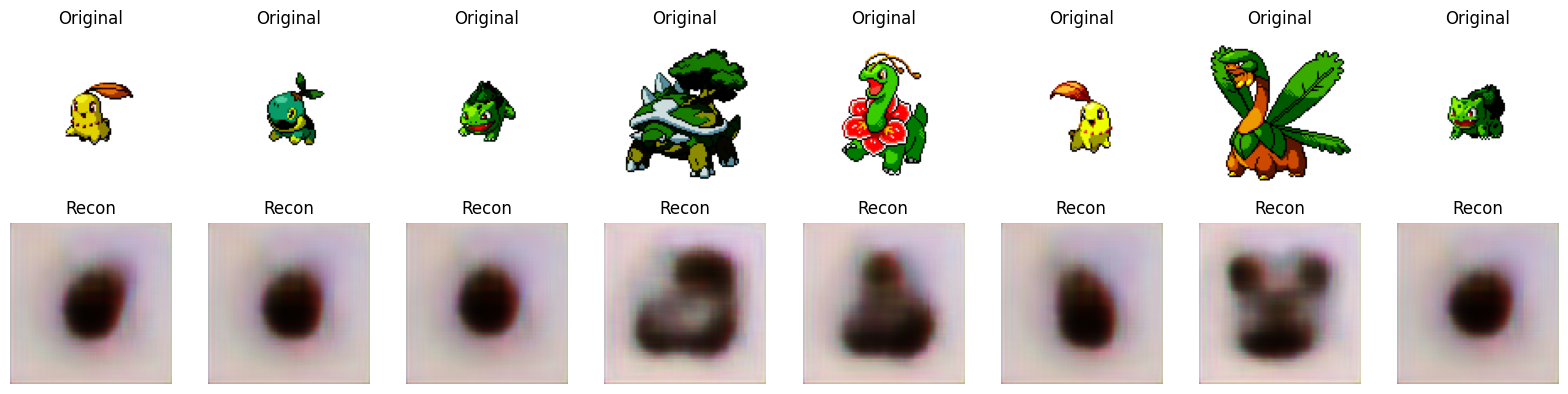

In [10]:
import matplotlib.pyplot as plt

model.eval()

batch = next(iter(val_loader))
x = batch["image"].to(device)[:8]

with torch.no_grad():
    recon, mu, logvar = model(x)

x_vis = x.cpu()
recon_vis = recon.cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):
    axes[0, i].imshow(x_vis[i].permute(1, 2, 0))
    axes[0, i].axis("off")
    axes[0, i].set_title("Original")

    axes[1, i].imshow(recon_vis[i].permute(1, 2, 0))
    axes[1, i].axis("off")
    axes[1, i].set_title("Recon")

plt.tight_layout()
plt.show()